In [1]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt, os, glob, scipy.stats as stats
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
df = pd.read_csv('../../results/psychopy/all_subjs_v2.csv')
print(df.shape)
df.head(5)

(2400, 159)


,thisN,thisTrialN,thisRepN,blockN,run,condition,trial_key,stim_file_pos,true_stim,noise_pos,...,stim_boundary_aligned,resp_boundary_aligned,rank_stim,rank_resp,baseline_dur,stim_dur,delay_dur,task_dur,anticipation_dur,feedback_dur
0,39.0,39.0,0.0,5.0,2.0,curv_comp,161.0,0.1,-0.38,1.0,...,-0.18,-0.060,4.5,3.0,0.991922,1.068953,1.342020,2.243022,0.259576,1.150575
1,38.0,38.0,0.0,5.0,2.0,curv_comp,183.0,1.3,-0.14,1.0,...,0.06,0.032,46.5,52.5,1.092014,0.993958,1.391935,2.149563,0.254444,1.027731
2,37.0,37.0,0.0,5.0,2.0,curv_comp,184.0,1.5,-0.10,1.0,...,0.10,0.012,50.5,44.0,0.941931,1.053243,1.441963,1.291744,0.263679,0.992746
3,36.0,36.0,0.0,5.0,2.0,curv_comp,178.0,0.9,-0.22,3.0,...,-0.02,0.024,36.5,47.0,0.941891,1.001235,1.392006,1.655112,0.247250,1.041000
4,35.0,35.0,0.0,5.0,2.0,curv_comp,181.0,1.1,-0.18,1.0,...,0.02,-0.028,42.5,17.0,1.091873,1.006109,1.291994,2.444801,0.248883,1.008979


### picking only newer subjects

In [3]:
# subj_mapping = {'kahini': 1.1, 'renee': 1.11, 'daria': 1.111, 'sienna': 1.1111}

df_subjs = df[df['subj'].isin([1.1, 1.11, 1.111, 1.1111])].copy()
# df_subjs = df[df['subj']==1.1111].copy()

print(df_subjs.shape)
print(df_subjs['subj'].unique())

(960, 159)
[1.1    1.11   1.111  1.1111]


### Binarized valence visuals

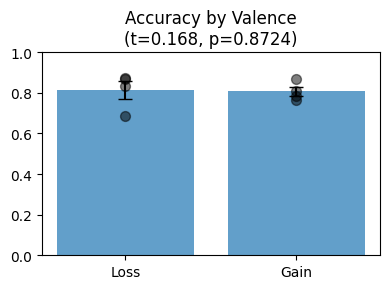

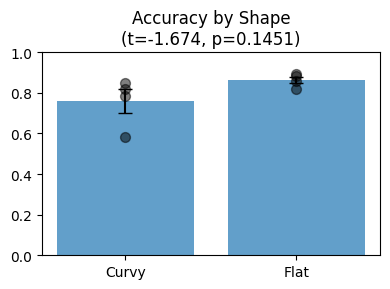

In [4]:
def plot_accuracy_bar_with_ttest(df, group_col, order=None, labels=None, title=None):
    
    # Get accuracy per subject per group
    subj_acc = df.groupby([group_col, 'subj'])['correct'].mean().reset_index()
    
    # Calculate group means and SEM
    acc_by_group = subj_acc.groupby(group_col)['correct'].agg(['mean', 'sem']).reindex(order)
    x_labels = [labels[v] if labels and v in labels else v for v in order]
    
    # T-test on subject means
    group_vals = [subj_acc[subj_acc[group_col] == g]['correct'].values for g in order]
    t_stat, p_val = stats.ttest_ind(group_vals[0], group_vals[1])
    
    # Plot bars with error bars
    plt.figure(figsize=(4, 3))
    x_pos = np.arange(len(order))
    plt.bar(x_pos, acc_by_group['mean'].values, yerr=acc_by_group['sem'].values, capsize=5, alpha=0.7)
    
    # Overlay subject points
    for i, g in enumerate(order):
        subj_vals = subj_acc[subj_acc[group_col] == g]['correct'].values
        plt.scatter([i] * len(subj_vals), subj_vals, alpha=0.5, s=50, color='black', zorder=3)
    
    plt.xticks(x_pos, x_labels)
    plt.title(f'{title}\n(t={t_stat:.3f}, p={p_val:.4f})')
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()
    
plot_accuracy_bar_with_ttest(df_subjs, 'valence', order=['pen', 'rew'], labels={'pen': 'Loss', 'rew': 'Gain'}, title='Accuracy by Valence')
plot_accuracy_bar_with_ttest(df_subjs, 'shape', order=['curv', 'flat'], labels={'curv': 'Curvy', 'flat': 'Flat'}, title='Accuracy by Shape')

In [6]:
def assign_valence_condition(row):
    if row['condition'] == 'baseline':
        return 'baseline'
    elif (row['blockN'] <= 3 and row['condition'] == 'curv_comp') or (row['blockN'] > 3 and row['condition'] == 'flat_comp'):
        return 'pen_comp'
    else:
        return 'rew_comp'

df_subjs['valence_condition'] = df_subjs.apply(assign_valence_condition, axis=1)
df_subjs['valence_condition'].value_counts()

valence_condition
rew_comp    320
baseline    320
pen_comp    320
Name: count, dtype: int64

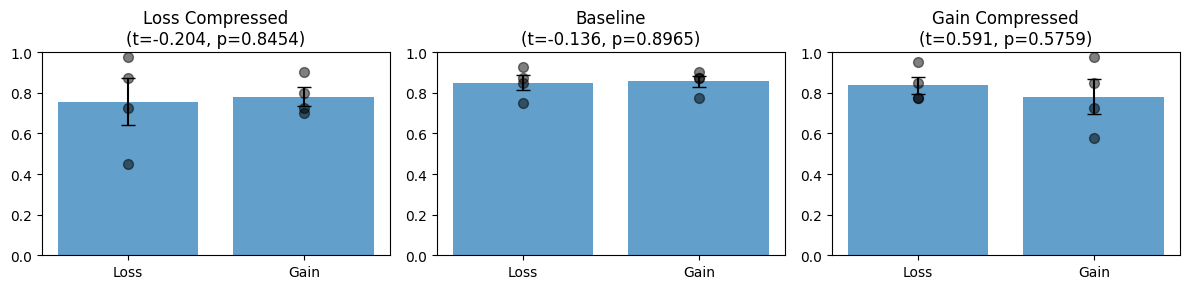

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3))

for ax_idx, val_cond in enumerate(['pen_comp', 'baseline', 'rew_comp']):
    
    # Filter data for this valence_condition
    df_cond = df_subjs[df_subjs['valence_condition'] == val_cond]
    
    # Get accuracy per subject per valence
    subj_acc = df_cond.groupby(['valence', 'subj'])['correct'].mean().reset_index()
    
    # Calculate group means and SEM
    acc_by_valence = subj_acc.groupby('valence')['correct'].agg(['mean', 'sem']).reindex(['pen', 'rew'])
    x_labels = ['Loss', 'Gain']
    
    # T-test on subject means
    group_vals = [subj_acc[subj_acc['valence'] == v]['correct'].values for v in ['pen', 'rew']]
    t_stat, p_val = stats.ttest_ind(group_vals[0], group_vals[1])
    
    # Plot
    ax = axs[ax_idx]
    x_pos = np.arange(2)
    ax.bar(x_pos, acc_by_valence['mean'].values, yerr=acc_by_valence['sem'].values, capsize=5, alpha=0.7)
    
    # Overlay subject points
    for i, v in enumerate(['pen', 'rew']):
        subj_vals = subj_acc[subj_acc['valence'] == v]['correct'].values
        ax.scatter([i] * len(subj_vals), subj_vals, alpha=0.5, s=50, color='black', zorder=3)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    
    # Set title with descriptive labels
    title_map = {'pen_comp': 'Loss Compressed', 'baseline': 'Baseline', 'rew_comp': 'Gain Compressed'}
    ax.set_title(f"{title_map[val_cond]}\n(t={t_stat:.3f}, p={p_val:.4f})")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

### valence_stim vs valence_resp scatter

In [5]:
n_rows, n_cols = 2, 3
fig, axs = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3*n_rows))
axs, ax = axs.flatten(), 0

for 
    axs[ax].set(xlabel='Valence stimulus', ylabel='Valence response', xlim=(0, 1), ylim=(0, 1))
    ax += 1

plt.suptitle('Valence aligned positions')
plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (2574927692.py, line 5)